# YAML-to-Fortran Pipeline with advanced debug outputs

This notebook demonstrates the full YAML → Fortran pipeline with the `ACGOrchestrator` and intentionally includes multiple, detailed debug outputs. Those debug diagnostics are part of its main value: they help inspect mapping decisions, preprocessing behavior, and code-generation internals.

## Setup

Import required modules and configure notebook-relative paths.

Note: this notebook includes detailed debug output by design.

In [1]:
import sys
from pathlib import Path
import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook-relative project paths (no user-specific absolute paths)
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    project_root = Path('..')
else:
    project_root = Path('.')

# Make project importable
sys.path.insert(0, str(project_root))

# Import ACG modules
from acg_brns.acg_orchestrator import ACGOrchestrator
from acg_brns.formula_evaluator import FormulaEvaluator
from acg_brns.yaml_to_acg_mapper import YAMLtoACGMapper

print(f"Project root (relative): {project_root}")
print(f"Working directory       : {notebook_dir.name}")

Project root: /mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage
Working directory: /mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage/notebooks


## Configure Paths

Define input YAML file and output directory for Fortran files.

In [2]:
# Input YAML configuration (relative to project root)
yaml_path = project_root / 'models' / 'canfield_equilibrium.yaml'

# Output directory for Fortran files (relative to project root)
output_dir = project_root / 'generated_fortran' / 'equilibrium'

# Verify input file exists
if not yaml_path.exists():
    raise FileNotFoundError(f"YAML file not found: {yaml_path}")

print(f"✓ Input YAML: {yaml_path}")
print(f"✓ Output directory: {output_dir}")

# Create output directory
output_dir.mkdir(parents=True, exist_ok=True)
print("✓ Output directory created/verified")

✓ Input YAML: /mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage/models/canfield_refactored.yaml
✓ Output directory: /mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage/generated_fortran/equilibrium
✓ Output directory created/verified


## Load and Inspect YAML Configuration

Load the YAML file and display key information.

In [3]:
# Load YAML
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

# Display configuration summary
print("Configuration Summary:")
print("=" * 60)
print(f"Species: {len(config['species'])}")
print(f"Reactions: {len(config['reactions'])}")
print(f"Bio-parameters: {len(config['parameters']['biogeochemical'])}")
print(f"Computed values: {len(config.get('computed_values', {}))}")

# Species breakdown
dissolved = [s for s in config['species'] if s.get('type') == 'dissolved']
solid = [s for s in config['species'] if s.get('type') == 'solid']
print(f"\nSpecies breakdown:")
print(f"  Dissolved: {len(dissolved)}")
print(f"  Solid: {len(solid)}")

# Reaction types
equilibrium = [r for r in config['reactions'] if r.get('equilibrium', False)]
kinetic = [r for r in config['reactions'] if not r.get('equilibrium', False)]
print(f"\nReaction types:")
print(f"  Kinetic: {len(kinetic)}")
print(f"  Equilibrium: {len(equilibrium)}")

Configuration Summary:
Species: 18
Reactions: 19
Bio-parameters: 57
Computed values: 6

Species breakdown:
  Dissolved: 12
  Solid: 6

Reaction types:
  Kinetic: 16
  Equilibrium: 3


### Species List

In [4]:
print("Dissolved Species:")
for i, s in enumerate(dissolved, 1):
    print(f"  {i:2d}. {s['name']:10s} (D0={s.get('transport_D0', 0):.2e})")

print(f"\nSolid Species:")
for i, s in enumerate(solid, len(dissolved)+1):
    print(f"  {i:2d}. {s['name']:10s}")

Dissolved Species:
   1. o2         (D0=2.96e+02)
   2. no3        (D0=3.07e+02)
   3. hco3       (D0=1.69e+02)
   4. co3        (D0=1.37e+02)
   5. co2        (D0=2.49e+02)
   6. hplus      (D0=1.77e+03)
   7. nh4        (D0=3.08e+02)
   8. so4        (D0=1.56e+02)
   9. mn2        (D0=9.60e+01)
  10. fe2        (D0=1.06e+02)
  11. h2s        (D0=2.58e+02)
  12. hs         (D0=3.05e+02)

Solid Species:
  13. ch2o      
  14. mno2      
  15. feoh3     
  16. mnco3     
  17. feco3     
  18. fes       


### Reaction List

In [5]:
print("Reactions:")
print("=" * 80)
for rxn in config['reactions']:
    rxn_type = "[EQ]" if rxn.get('equilibrium', False) else "[KIN]"
    print(f"{rxn['id']:2d}. {rxn_type} {rxn['name']:30s}")
    
    # Show stoichiometry
    stoich = rxn.get('stoichiometry', {})
    # Convert values to float for comparison
    stoich_float = {}
    for k, v in stoich.items():
        try:
            stoich_float[k] = float(v) if isinstance(v, str) else v
        except (ValueError, TypeError):
            stoich_float[k] = 0.0
    
    reactants = [f"{v:+.1f} {k}" for k, v in stoich_float.items() if v < 0]
    products = [f"{v:+.1f} {k}" for k, v in stoich_float.items() if v > 0]
    
    if reactants and products:
        print(f"     {' + '.join([r.replace('-', '').replace('+', '') for r in reactants])} → {' + '.join([p.replace('+', '') for p in products])}")
    print()

Reactions:
 1. [KIN] aerobic_respiration           

 2. [KIN] denitrification               

 6. [KIN] sulfate_reduction             

 7. [KIN] nitrification                 
     1.0 nh4 + 2.0 o2 + 2.0 hco3 → 1.0 no3 + 2.0 co2

 8. [KIN] manganese_reduction           

 9. [KIN] manganese_oxidation           
     1.0 mn2 + 2.0 hco3 → 2.0 co2

10. [KIN] iron_reduction                

11. [KIN] iron_oxidation_o2             
     1.0 fe2 + 2.0 hco3 → 2.0 co2

12. [KIN] iron_oxidation_mno2           
     1.0 mno2 → 2.0 feoh3

 3. [EQ] carbonate_equilibrium_1       
     1.0 hco3 + 1.0 hplus → 1.0 co2

 4. [EQ] carbonate_equilibrium_2       
     1.0 co3 + 1.0 hplus → 1.0 hco3

13. [EQ] sulfide_dissociation          
     1.0 hs + 1.0 hplus → 1.0 h2s

14. [KIN] sulfide_oxidation_o2          
     2.0 o2 + 1.0 h2s + 2.0 hco3 → 1.0 so4 + 2.0 co2

15. [KIN] sulfide_oxidation_mno2        

16. [KIN] sulfide_oxidation_feoh3       

17. [KIN] mnco3_precipitation           

18. [KIN] feco

## Create ACG Orchestrator

Initialize the orchestrator with configuration.

In [6]:
# Create orchestrator with verbose output
orchestrator = ACGOrchestrator(
    yaml_path=str(yaml_path),
    output_dir=str(output_dir),
    verbose=True
)

print("✓ Orchestrator created")

ACGOrchestrator initialized:
  YAML: /mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage/models/canfield_refactored.yaml
  Output: /mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage/generated_fortran/equilibrium
✓ Orchestrator created


## Phase 1: Load and Validate Configuration

In [7]:
config = orchestrator.load_config()
print("\n✓ Phase 1 complete")


=== Phase 1: Loading Configuration ===
✓ Loaded configuration from canfield_refactored.yaml
  Species: 18
  Reactions: 19

✓ Phase 1 complete


## Phase 2: Evaluate Formulas

Evaluate all mathematical expressions and computed values.

In [8]:
params = orchestrator.evaluate_formulas()

# Show some evaluated parameters
print("\nSample evaluated parameters:")
sample_keys = list(params.keys())#[:10]
for key in sample_keys:
    val = params[key]
    if isinstance(val, (int, float)):
        print(f"  {key:15s} = {val:.6e}")
    else:
        print(f"  {key:15s} = {val}")

print("\n✓ Phase 2 complete")


=== Phase 2: Evaluating Formulas ===
✓ Evaluated 108 parameters

Sample evaluated parameters:
  al              = 1.000000e-05
  q0              = 0.000000e+00
  w0              = 3.980000e-01
  Db0             = 2.750000e+01
  por0            = 8.500000e-01
  area0           = 1.000000e+00
  t_celsius       = 1.030000e+01
  salin           = 3.500000e+01
  delt            = 1.000000e-07
  depthmax        = 5.000000e+01
  endt            = 5.000000e+00
  iq              = 0.000000e+00
  iw              = 0.000000e+00
  iDb             = 1.000000e+00
  ipor            = 0.000000e+00
  igrid           = 1.000000e+00
  iarea           = 0.000000e+00
  kfox            = 2.210000e-01
  kmo2            = 8.000000e-06
  ho2             = 0.000000e+00
  kmno3           = 1.000000e-05
  nro             = 4.500000e+00
  h1              = 1.000000e+00
  hno3            = 0.000000e+00
  kmno2           = 2.000000e-06
  hmn4            = 0.000000e+00
  kmfeoh3         = 5.000000e-06
  hfe3        

## Phase 3: Map to ACG Structures

Convert YAML data to ACG-compatible structures.

In [9]:
acg_data = orchestrator.map_to_acg_structures()

# Display structure information
print("\nACG Data Structures:")
print("=" * 60)
print(f"Variables (species): {len(acg_data['variables'])}")
print(f"Bio-parameters: {len(acg_data['bio_name'])}")
print(f"Reactions: {acg_data['nreactions']}")
print(f"Stoichiometry matrix: {acg_data['stoich_matrix'].shape}")

print("\n✓ Phase 3 complete")


=== Phase 3: Mapping to ACG Structures ===
✓ Mapped structures:
  Variables: 18
    Dissolved: 12
    Solid: 6
  Reactions: 19
  Bio-parameters: 57

ACG Data Structures:
Variables (species): 18
Bio-parameters: 57
Reactions: 19
Stoichiometry matrix: (19, 18)

✓ Phase 3 complete


### Visualize Stoichiometry Matrix

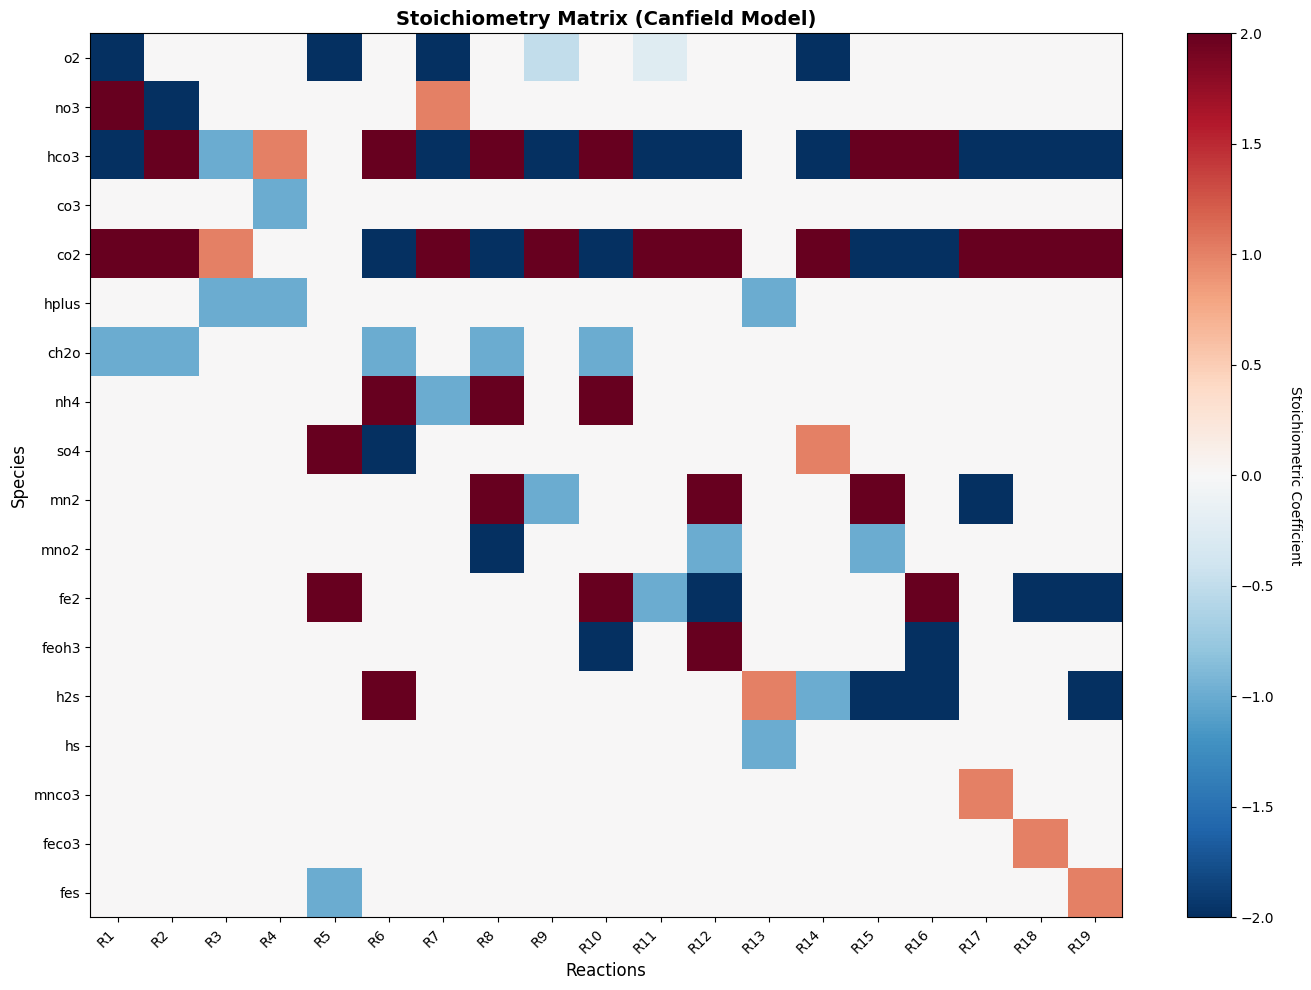


Stoichiometry Matrix Statistics:
  Shape: (18, 19)
  Non-zero entries: 89 / 342
  Sparsity: 74.0%


In [10]:
# Create stoichiometry matrix heatmap
stoich_matrix = np.array(acg_data['stoich_matrix'].tolist()).astype(float)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(stoich_matrix.T, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)

# Set ticks and labels
ax.set_xticks(range(acg_data['nreactions']))
ax.set_xticklabels([f"R{i+1}" for i in range(acg_data['nreactions'])], rotation=45, ha='right')
ax.set_yticks(range(len(acg_data['variables'])))
ax.set_yticklabels(acg_data['variables'])

ax.set_xlabel('Reactions', fontsize=12)
ax.set_ylabel('Species', fontsize=12)
ax.set_title('Stoichiometry Matrix (Canfield Model)', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Stoichiometric Coefficient', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

# Print matrix statistics
non_zero = np.count_nonzero(stoich_matrix)
total = stoich_matrix.size
sparsity = (total - non_zero) / total * 100
print(f"\nStoichiometry Matrix Statistics:")
print(f"  Shape: {stoich_matrix.T.shape}")
print(f"  Non-zero entries: {non_zero} / {total}")
print(f"  Sparsity: {sparsity:.1f}%")

### Species Index Mapping

In [11]:
print("Species → Fortran Index Mapping:")
print("=" * 50)
for name, idx in acg_data['species_map'].items():
    species_type = "[D]" if idx <= acg_data['ndissolved'] else "[S]"
    print(f"{species_type} {name:10s} → sp({idx:2d},j)")

Species → Fortran Index Mapping:
[D] o2         → sp( 1,j)
[D] no3        → sp( 2,j)
[D] hco3       → sp( 3,j)
[D] co3        → sp( 4,j)
[D] co2        → sp( 5,j)
[D] hplus      → sp( 6,j)
[D] ch2o       → sp( 7,j)
[D] nh4        → sp( 8,j)
[D] so4        → sp( 9,j)
[D] mn2        → sp(10,j)
[D] mno2       → sp(11,j)
[D] fe2        → sp(12,j)
[S] feoh3      → sp(13,j)
[S] h2s        → sp(14,j)
[S] hs         → sp(15,j)
[S] mnco3      → sp(16,j)
[S] feco3      → sp(17,j)
[S] fes        → sp(18,j)


## Phase 4: Pre-processing (Gaussian Elimination)

Execute p0-p10 to reduce the stoichiometric system.

In [12]:
reduced_system = orchestrator.run_preprocessing()

print("\nReduced System:")
print("=" * 60)
print(f"Residual equations: {len(reduced_system['func'])}")
print(f"Jacobian matrix: {reduced_system['jacobian'].shape}")
print(f"Conservation rows: {reduced_system['conservation_rows']}")
print(f"Pivot rows: {len(reduced_system['pivot_rows'])}")

print("\n✓ Phase 4 complete")


=== Phase 4: Pre-processing (p0-p10) ===
  Running Gaussian elimination...
p4: Building coefficient matrix from equations...
  Coefficient matrix: (18, 19)
Detecting conservation laws from coefficient matrix...
  Found 5 conservation law(s)
    Conservation law 1: Matrix([[-2, -7/2, 0, -1, 1, 1, 1263*SD/400, 5/2, -5, 1, -2*SD, 1, -3*SD/2, 1, 0, 0, 0, 0]])
    Conservation law 2: Matrix([[0, 1, 1, 2, 0, -1, 0, -1, 2, -2, 0, -2, 0, 0, 1, 0, 0, 0]])
    Conservation law 3: Matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1/SD, 1, 0, 0, 0, 0, 1, 0, 0]])
    Conservation law 4: Matrix([[0, 0, 1/SD, 1/SD, 1/SD, 0, 1, 0, 0, -1/SD, -1, 0, 0, 0, 0, 0, 1, 0]])
    Conservation law 5: Matrix([[0, 0, -1/SD, -1/SD, -1/SD, 0, -1, 0, 0, 1/SD, 1, 1/SD, 1, 0, 0, 0, 0, 1]])
  Augmented matrix shape: (18, 37)
p5: Gaussian elimination (Maple-style: NO normalization, full elimination)...
  Column 0: using row 2 as pivot
  Column 1: using row 3 as pivot
  Column 2: using row 5 as pivot
  Column 3: using row 0 as pivot


### Visualize Jacobian Structure and Run Structural Checks

The checks below are intentionally **value-agnostic** where possible.
They focus on sparsity structure (e.g., empty rows/columns, zero diagonal entries) so they remain useful even when Jacobian values change between model variants.

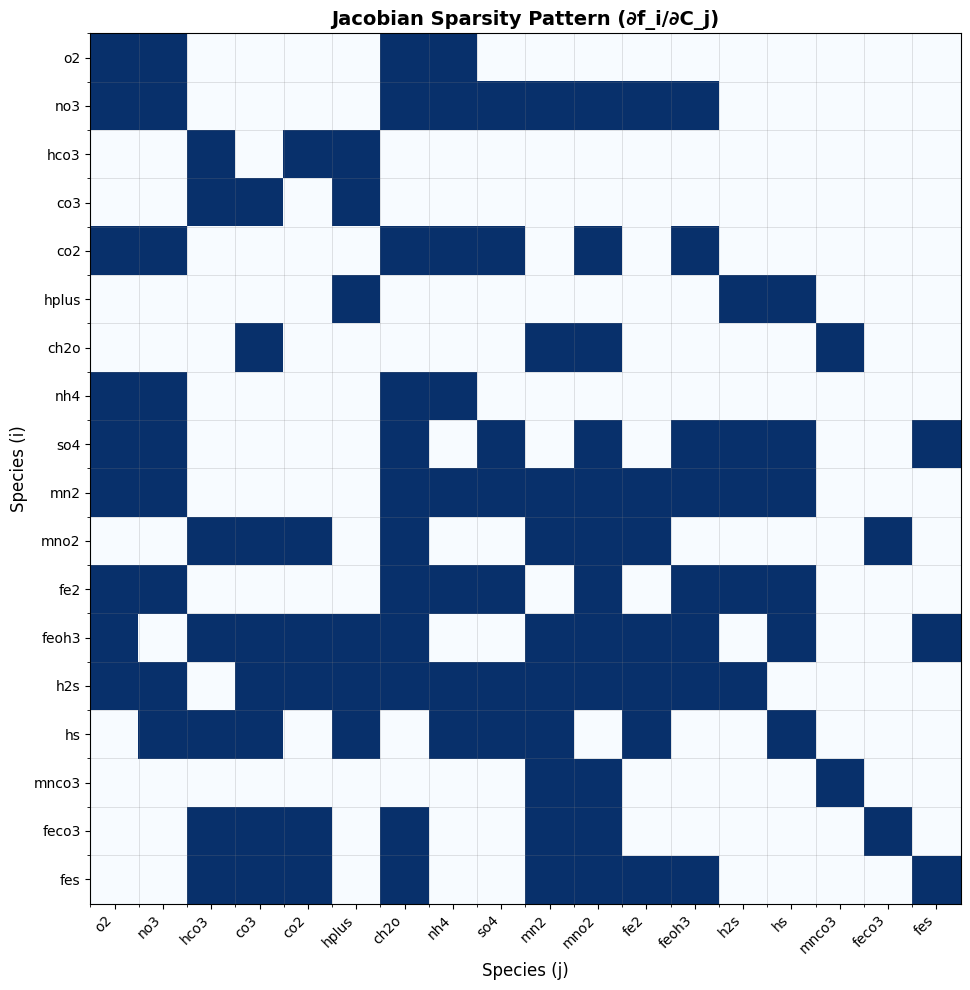


Jacobian Statistics:
  Shape: (18, 18)
  Non-zero entries: 127 / 324
  Sparsity: 60.8%


In [13]:
# Convert Jacobian to numeric structure for visualization
jacobian = reduced_system['jacobian']
ncompo = len(acg_data['variables'])

# Check which entries are non-zero (symbolically)
jac_structure = np.zeros((ncompo, ncompo), dtype=int)
for i in range(ncompo):
    for j in range(ncompo):
        if jacobian[i, j] != 0:
            jac_structure[i, j] = 1

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(jac_structure, cmap='Blues', aspect='equal')

# Set ticks and labels
ax.set_xticks(range(ncompo))
ax.set_xticklabels(acg_data['variables'], rotation=45, ha='right')
ax.set_yticks(range(ncompo))
ax.set_yticklabels(acg_data['variables'])

ax.set_xlabel('Species (j)', fontsize=12)
ax.set_ylabel('Species (i)', fontsize=12)
ax.set_title('Jacobian Sparsity Pattern (∂f_i/∂C_j)', fontsize=14, fontweight='bold')

# Add grid
ax.set_xticks(np.arange(ncompo) - 0.5, minor=True)
ax.set_yticks(np.arange(ncompo) - 0.5, minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------
# Structural diagnostics (robust)
# -------------------------------
non_zero_jac = int(np.count_nonzero(jac_structure))
total_jac = int(jac_structure.size)
sparsity_jac = (total_jac - non_zero_jac) / total_jac * 100
diag = np.diag(jac_structure)
zero_diag_idx = [i for i, v in enumerate(diag) if v == 0]
row_nnz = jac_structure.sum(axis=1)
col_nnz = jac_structure.sum(axis=0)
empty_rows = [i for i, v in enumerate(row_nnz) if v == 0]
empty_cols = [i for i, v in enumerate(col_nnz) if v == 0]

print(f"\nJacobian Statistics:")
print(f"  Shape: {jac_structure.shape}")
print(f"  Non-zero entries: {non_zero_jac} / {total_jac}")
print(f"  Sparsity: {sparsity_jac:.1f}%")
print(f"  Zero diagonal entries: {len(zero_diag_idx)} / {ncompo}")

if zero_diag_idx:
    names = [acg_data['variables'][i] for i in zero_diag_idx]
    print(f"  Rows with J[i,i] = 0: {zero_diag_idx}")
    print(f"  Affected species: {names}")

if empty_rows:
    print(f"  ⚠ Empty Jacobian rows (no dependencies): {empty_rows}")
if empty_cols:
    print(f"  ⚠ Empty Jacobian columns (no variable influence): {empty_cols}")
if not empty_rows and not empty_cols:
    print("  ✓ No empty rows/columns in Jacobian structure")

# Optional lightweight numeric rank smoke test (value-dependent)
# This is only a heuristic and can vary with parameter values.
try:
    import random
    import sympy as sp

    free_syms = sorted(list(jacobian.free_symbols), key=lambda s: str(s))
    if free_syms:
        trials = 3
        ranks = []
        for _ in range(trials):
            subs = {s: random.uniform(0.5, 2.0) for s in free_syms}
            j_num = np.array(sp.Matrix(jacobian).subs(subs), dtype=float)
            ranks.append(int(np.linalg.matrix_rank(j_num)))
        print(f"  Rank smoke test over {trials} random substitutions: {ranks} (target: {ncompo})")
        if min(ranks) < ncompo:
            print("  ⚠ Potential rank deficiency for some parameter states")
        else:
            print("  ✓ Full rank in sampled substitutions")
except Exception as exc:
    print(f"  (Rank smoke test skipped: {exc})")

### Show Sample Residual Equations

In [14]:
from sympy import pretty

print("Sample Residual Equations (first 3):")
print("=" * 80)
for i in range(min(3, len(reduced_system['func']))):
    species = acg_data['variables'][i]
    func = reduced_system['func'][i]
    print(f"\nf_{i+1} (d{species}/dt):")
    print(f"  {func}")
    print()

Sample Residual Equations (first 3):

f_1 (do2/dt):
  (-968*delt*(21*SD*kfox*sp(7,j)*(ho2*kmo2 - sp(1,j)*(ho2 - 1.0)) + 200*kmo2*knit*sp(1,j)*sp(8,j)) + kmo2*(-18123*SD*sp(7,j) + 18123*SD*spold(7,j) + 21000*sp(2,j) - 172600*sp(8,j) - 21000*spold(2,j) + 172600*spold(8,j)))/(16800*delt*kmo2)


f_2 (dno3/dt):
  (-200*delt*(84*SD*hso4*kfox*sp(7,j)*(hso4f2*kmso4 - sp(9,j)*(hso4f2 - 1.0))*(hfe3*(-hfe3f2*kmfeoh3 + sp(13,j)*(hfe3f2 - 1.0))*(hmn4*(hmn4f2*kmno2 - sp(11,j)*(hmn4f2 - 1.0))*(hno3*(hno3f2*kmno3 + sp(2,j)*(1.0 - hno3f2))*(kmo2*(1 - ho2) - sp(1,j)*(1.0 - ho2)) - kmno3*kmo2*(1 - ho2) + kmno3*sp(1,j)*(1.0 - ho2)) - hno3*kmno2*(hno3f2*kmno3 - sp(2,j)*(hno3f2 - 1.0))*(-kmo2*(ho2 - 1) + sp(1,j)*(ho2 - 1.0)) - kmno2*kmno3*kmo2*(ho2 - 1) + kmno2*kmno3*sp(1,j)*(ho2 - 1.0)) + hmn4*kmfeoh3*(hmn4f2*kmno2 - sp(11,j)*(hmn4f2 - 1.0))*(-hno3*(hno3f2*kmno3 - sp(2,j)*(hno3f2 - 1.0))*(kmo2*(ho2 - 1) - sp(1,j)*(ho2 - 1.0)) + kmno3*kmo2*(ho2 - 1) - kmno3*sp(1,j)*(ho2 - 1.0)) + hno3*kmfeoh3*kmno2*(hno3f2*

## Phase 5: Generate Fortran Code

Generate all Fortran subroutines using acg0-acg17b functions.

In [15]:
try:
    result = orchestrator.run_code_generation()
    print("\n✓ Phase 5 complete")
    print(f"\nGenerated {len(result['files_generated'])} Fortran files")
    print(f"\nNote: Using Maple-compatible ACG function names (acg0, acg1, ..., acg17b)")
except Exception as e:
    print(f"\n⚠️  Code generation encountered an issue: {e}")
    print(f"\nNote: Some ACG functions may need additional implementation.")
    print(f"Pre-processing (Phases 1-4) completed successfully.")
    import traceback
    traceback.print_exc()


=== Phase 5: Code Generation (acg0-acg17b) ===
ACG initialized: output=/mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage/generated_fortran/equilibrium, style=f77
  Generating model structure...
✓ Generated: common_geo.inc
  Generating boundary conditions...
✓ Generated: boundaries.f
  Generating diffusion...
✓ Generated: molecular.f
  Generating biogeochemical parameters...
✓ Generated: biogeo.f
  Generating residual function...
✓ Generated: residual.f
  Generating Jacobian...
✓ Generated: jacobian.f
  Generating output specifications...
✓ Generated: output.f
  Generating physical parameters...
✓ Generated: basic.f
  Generating initial conditions...
✓ Generated: initialcond.f
  Generating net reaction rates...
✓ Generated: ssrates.f
  Generating no-transport list...
✓ Generated: notransport.f
  Generating reaction rates...
✓ Generated: rates.f
  Generating solid species identification...
✓ Generated: issolid.f
  Generating spatial switches (stub)...
✓ Generated: switches.f
  Genera

In [16]:
# DEBUG: Check nnodes value
print(f"\nDEBUG: config['grid'] = {orchestrator.config.get('grid', {})}")
grid_cfg = orchestrator.config.get('grid', {})
nnodes_val = grid_cfg.get('nnodes', 100)
print(f"DEBUG: nnodes from YAML = {nnodes_val}")
print(f"DEBUG: nx should be = {2 * nnodes_val - 1}")


DEBUG: config['grid'] = {'nnodes': 111, 'type': 1}
DEBUG: nnodes from YAML = 111
DEBUG: nx should be = 221


In [17]:
# Check physical_flags order
phys_flags = orchestrator.config.get('parameters', {}).get('physical_flags', {})
print(f"physical_flags keys: {list(phys_flags.keys())}")
print(f"physical_flags values: {list(phys_flags.values())}")

# Also check what orchestrator will extract
from acg_brns.acg_orchestrator import ACGOrchestrator
import inspect
source = inspect.getsource(orchestrator.run_code_generation)
# Print only the acg0 relevant lines
lines = source.split('\n')
for i, line in enumerate(lines):
    if 'phys_names2' in line or 'physical_flags' in line:
        print(f"Line {i}: {line}")

physical_flags keys: ['iq', 'iw', 'iDb', 'ipor', 'igrid', 'iarea']
physical_flags values: [0, 0, 1, 0, 1, 0]
Line 27:         phys_names, phys_vals, phys_names2, phys_vals2 = self._extract_physical_codegen_data()
Line 30:                      phys_names, phys_vals, phys_names2, phys_vals2)
Line 81:         phys_names, phys_vals, phys_names2, phys_vals2 = self._extract_physical_codegen_data()
Line 82:         self.acg.acg8(phys_names, phys_vals, phys_names2, phys_vals2)


In [18]:
# Force complete module reload - clear all cached modules
import sys
for module_name in list(sys.modules.keys()):
    if 'acg_brns' in module_name:
        del sys.modules[module_name]

# Re-import fresh
import importlib
import acg_brns.acg_orchestrator
importlib.reload(acg_brns.acg_orchestrator)
from acg_brns.acg_orchestrator import ACGOrchestrator

print("✓ Modules reloaded")

✓ Modules reloaded


## List Generated Files

Show all Fortran files created in the output directory.

In [19]:
# List all .f and .f90 files in output directory
fortran_files = sorted(output_dir.glob('*.f*'))

if fortran_files:
    print(f"Generated Fortran files in {output_dir.relative_to(project_root)}:")
    print("=" * 60)
    for i, ffile in enumerate(fortran_files, 1):
        size = ffile.stat().st_size
        print(f"{i:2d}. {ffile.name:25s} ({size:7,d} bytes)")
    print(f"\nTotal: {len(fortran_files)} files")
else:
    print(f"No Fortran files found in {output_dir}")

Generated Fortran files in generated_fortran/equilibrium:
 1. basic.f                   (    453 bytes)
 2. biogeo.f                  (  1,482 bytes)
 3. boundaries.f              (  1,779 bytes)
 4. initialcond.f             (  3,570 bytes)
 5. issolid.f                 (    471 bytes)
 6. jacobian.f                ( 27,737 bytes)
 7. molecular.f               (  1,011 bytes)
 8. notransport.f             (    186 bytes)
 9. output.f                  ( 12,090 bytes)
10. parameters.f              (  1,786 bytes)
11. rates.f                   (  2,704 bytes)
12. residual.f                (  9,685 bytes)
13. ssrates.f                 ( 19,773 bytes)
14. switches.f                (    235 bytes)

Total: 14 files


## Summary

Display final pipeline summary.

In [20]:
print("="*80)
print("PIPELINE SUMMARY")
print("="*80)
print(f"Input YAML: {yaml_path.relative_to(project_root)}")
print(f"Output Directory: {output_dir.relative_to(project_root)}")
print()
print("Model Configuration:")
print(f"  Species: {acg_data['ncompo']} ({acg_data['ndissolved']} dissolved + {acg_data['nsolids']} solid)")
print(f"  Reactions: {acg_data['nreactions']}")
print(f"  Bio-parameters: {len(acg_data['bio_name'])}")
print()
print("Reduced System:")
print(f"  Residual equations: {len(reduced_system['func'])}")
print(f"  Jacobian matrix: {reduced_system['jacobian'].shape}")
print(f"  Conservation laws: {len(reduced_system.get('conservation_basis', []))}")
print()
if fortran_files:
    print(f"Generated Files: {len(fortran_files)}")
    total_size = sum(f.stat().st_size for f in fortran_files)
    print(f"Total size: {total_size:,} bytes")
print("="*80)
print("✓ PIPELINE COMPLETE")
print("="*80)

PIPELINE SUMMARY
Input YAML: models/canfield_refactored.yaml
Output Directory: generated_fortran/equilibrium

Model Configuration:
  Species: 18 (12 dissolved + 6 solid)
  Reactions: 19
  Bio-parameters: 57

Reduced System:
  Residual equations: 18
  Jacobian matrix: (18, 18)
  Conservation laws: 5

Generated Files: 14
Total size: 82,962 bytes
✓ PIPELINE COMPLETE


## Next Steps

1. **Compile Fortran Code**: Use the BRNS Makefile to compile generated subroutines
2. **Run Simulation**: Execute BRNS with the new model
3. **Analyze Results**: Visualize concentration profiles and reaction rates